In [7]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from scipy.stats import chi2_contingency
import math
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.feature_selection import SelectFromModel, RFE
from itertools import combinations

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import MultinomialNB

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

In [9]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [10]:
exps_dir = "../../exps"
if os.path.exists(exps_dir) == False: # tạo thư mục (nếu chưa có)
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)
test_size=0.33
seed=42


# 5. Xây dựng và đánh giá mô hình học sâu Neutual Network

In [11]:
x_train=pd.read_excel(f'{save_dir}/x_train.xlsx')
y_train=pd.read_excel(f'{save_dir}/y_train.xlsx')
x_test=pd.read_excel(f'{save_dir}/x_test.xlsx')
y_test=pd.read_excel(f'{save_dir}/y_test.xlsx')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Load data
df = pd.read_csv("../../data/banknote_authentication.csv")
df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

# Tách X, y
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===== MODEL (Neural Network kiểu sklearn) =====
model = MLPClassifier(
    hidden_layer_sizes=(240, 120, 60, 30, 15),  # giống Dense của bạn
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [13]:
# ===== MODEL (UPGRADE) =====
model = MLPClassifier(
    hidden_layer_sizes=(240, 120, 60, 30, 15),
    activation='relu',
    solver='adam',

    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,

    random_state=42,
    verbose=True
)

# ===== TRAIN =====
model.fit(X_train, y_train)

# ===== PREDICT =====
y_pred = model.predict(X_test)

# ===== EVALUATE =====
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

# ===== SAVE =====
import joblib
joblib.dump(model, "banknote_model.pkl")
joblib.dump(scaler, "scaler.pkl")

Iteration 1, loss = 0.61868214
Validation score: 0.836364
Iteration 2, loss = 0.48411716
Validation score: 0.927273
Iteration 3, loss = 0.34548985
Validation score: 0.954545
Iteration 4, loss = 0.21550147
Validation score: 0.972727
Iteration 5, loss = 0.11163136
Validation score: 0.972727
Iteration 6, loss = 0.05206539
Validation score: 0.981818
Iteration 7, loss = 0.02745160
Validation score: 0.981818
Iteration 8, loss = 0.01625547
Validation score: 1.000000
Iteration 9, loss = 0.00955560
Validation score: 1.000000
Iteration 10, loss = 0.00663457
Validation score: 1.000000
Iteration 11, loss = 0.00417492
Validation score: 1.000000
Iteration 12, loss = 0.00281848
Validation score: 1.000000
Iteration 13, loss = 0.00221957
Validation score: 1.000000
Iteration 14, loss = 0.00164593
Validation score: 1.000000
Iteration 15, loss = 0.00133544
Validation score: 1.000000
Iteration 16, loss = 0.00111206
Validation score: 1.000000
Iteration 17, loss = 0.00098407
Validation score: 1.000000
Iterat

['scaler.pkl']

Epoch 1/50 done
Epoch 2/50 done
Epoch 3/50 done
Epoch 4/50 done
Epoch 5/50 done
Epoch 6/50 done
Epoch 7/50 done
Epoch 8/50 done
Epoch 9/50 done
Epoch 10/50 done
Epoch 11/50 done
Epoch 12/50 done
Epoch 13/50 done
Epoch 14/50 done
Epoch 15/50 done
Epoch 16/50 done
Epoch 17/50 done
Epoch 18/50 done
Epoch 19/50 done
Epoch 20/50 done
Epoch 21/50 done
Epoch 22/50 done
Epoch 23/50 done
Epoch 24/50 done
Epoch 25/50 done
Epoch 26/50 done
Epoch 27/50 done
Epoch 28/50 done
Epoch 29/50 done
Epoch 30/50 done
Epoch 31/50 done
Epoch 32/50 done
Epoch 33/50 done
Epoch 34/50 done
Epoch 35/50 done
Epoch 36/50 done
Epoch 37/50 done
Epoch 38/50 done
Epoch 39/50 done
Epoch 40/50 done
Epoch 41/50 done
Epoch 42/50 done
Epoch 43/50 done
Epoch 44/50 done
Epoch 45/50 done
Epoch 46/50 done
Epoch 47/50 done
Epoch 48/50 done
Epoch 49/50 done
Epoch 50/50 done


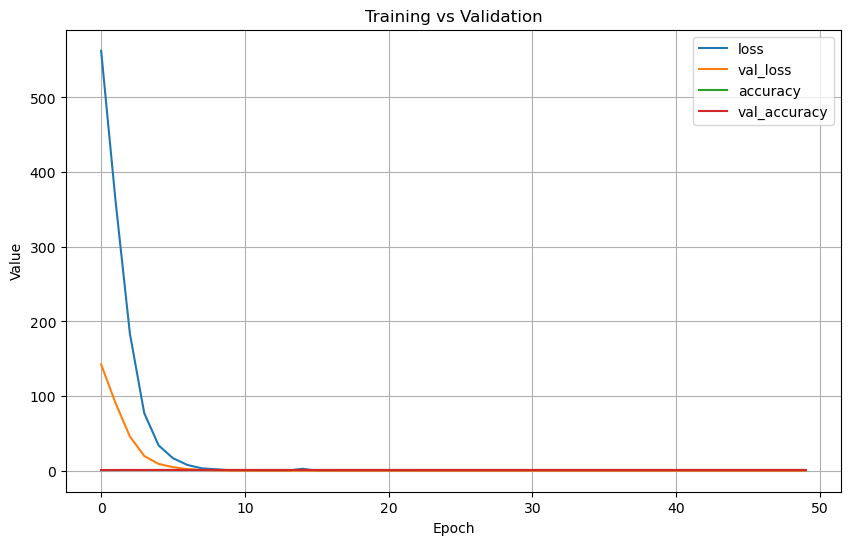

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss, accuracy_score

# ===== INIT MODEL =====
model = MLPClassifier(
    hidden_layer_sizes=(240,120,60,30,15),
    activation='relu',
    solver='adam',
    max_iter=1,           # 👈 mỗi lần fit = 1 epoch
    warm_start=True,      # 👈 giữ weight cũ
    random_state=42
)

# ===== LIST LƯU DATA =====
train_loss = []
val_loss = []
train_acc = []
val_acc = []

epochs = 50

# ===== TRAIN LOOP =====
for i in range(epochs):
    model.fit(X_train, y_train)

    # Predict prob
    y_train_prob = model.predict_proba(X_train)
    y_val_prob = model.predict_proba(X_test)

    # Loss
    train_loss.append(log_loss(y_train, y_train_prob, normalize=False))
    val_loss.append(log_loss(y_test, y_val_prob, normalize=False))

    # Accuracy
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    val_acc.append(accuracy_score(y_test, model.predict(X_test)))

    print(f"Epoch {i+1}/{epochs} done")


# 📈 VẼ BIỂU ĐỒ (giống Keras)
plt.figure(figsize=(10,6))

plt.plot(train_loss, label='loss')
plt.plot(val_loss, label='val_loss')
plt.plot(train_acc, label='accuracy')
plt.plot(val_acc, label='val_accuracy')

plt.title("Training vs Validation")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
from sklearn.metrics import accuracy_score

# Probability (giống predict trong Keras)
probabilities = model.predict_proba(X_test)

# Prediction (argmax tương đương)
predictions = np.argmax(probabilities, axis=1)

# Evaluate (thay model.evaluate)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 1.0


In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict
predictions = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


Confusion Matrix:
[[148   0]
 [  0 127]]


### Kết luận:
- Nhóm xây dựng một mạng Netual network ứng dụng kỹ thuật trong học sâu như callbacks, đánh trọng số,.... Nhưng không khắc phục được tình trạng (imbalanced variable).

In [17]:
def check_result(prediction):
    if isinstance(prediction, (np.ndarray, pd.Series)):
        prediction = prediction.item()  # Hoặc sử dụng prediction[0] hoặc prediction.iloc[0]
    if prediction==1:
        return "Y"
    else:
        return "N"

In [18]:
import random as rd
def check_output(stt, model, X_test, y_test):
    print(f"Lần thứ {stt}: ")

    indx = rd.randint(0, len(X_test) - 1)

    sample = X_test[indx].reshape(1, -1)
    y_true = y_test[indx]

    prob = model.predict_proba(sample)
    y_pred = np.argmax(prob)

    print("Probability:", prob)
    print("True       :", y_true)
    print("Predicted  :", y_pred)
    print("----------------------------")

    return y_true == y_pred

In [19]:
solandung = 0

for i in range(len(X_test)):
    # Lấy sample
    sample = X_test[i].reshape(1, -1)
    
    # Predict
    y_pred = model.predict(sample)[0]
    y_true = y_test[i]

    print("True     :", y_true)
    print("Predicted:", y_pred)
    print("----------------------------")

    if y_true == y_pred:
        solandung += 1

print("Số lần dự đoán đúng:", solandung)

True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 1
Predicted: 1
----------------------------
True     : 1
Predicted: 1
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 1
Predicted: 1
----------------------------
True     : 0
Predicted: 0
----------------------------
True     : 1
Predicted: 1
----------------------------
True     : 1
Predicted: 1
----------------------------
True     : 1
Predicted: 1
----------------------------
True     :

In [20]:
print(f"Số lần dự đoán đúng: {solandung} chiếm khoảng {(solandung/len(x_test))*100}% tổng lần dự đoán")

Số lần dự đoán đúng: 275 chiếm khoảng 67.90123456790124% tổng lần dự đoán
